# Calibración del modelo de riesgo de hurto

Notebook de calibración sobre el lakehouse (datos sintéticos o reales).

1. Valida la **minería de etiquetas** contra la verdad-terreno (recall, §22.8).
2. Compara los **métodos de PU learning** por **Precision@k** (§17.2).
3. Barre un **umbral** de minería y grafica recall vs precisión.

> Con datos reales, sustituye `theft_labels` por tus hurtos confirmados.

In [1]:
import os, warnings; warnings.filterwarnings('ignore')
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from lossan.config import load_config
from lossan.lakehouse import Lakehouse
from lossan.ml import (mine_labels, validate_against_confirmed,
                       train_risk_model, precision_at_k, energy_recoverable_at_k)
from lossan.ml.pu import PU_METHODS

# Ruta del lakehouse (robusta: env var, ./data/lake o ../data/lake)
ROOT = os.environ.get('LOSSAN_LAKEHOUSE', 'data/lake')
if not os.path.isdir(ROOT) and os.path.isdir(os.path.join('..','data','lake')):
    ROOT = os.path.join('..','data','lake')
FEEDER = 'F0000'        # None para todos los alimentadores
cfg = load_config()
lake = Lakehouse(ROOT)
cons = lake.read_entity('bronze','consumption', FEEDER)
cust = lake.read_entity('bronze','customers', FEEDER)
labels = lake.read_entity('bronze','theft_labels', FEEDER)
assert not cons.empty, f'No hay datos en {ROOT}. Ejecuta lossan generate/run.'
print(f'{cust.shape[0]} clientes · {cons["year_month"].nunique()} meses · {ROOT}')
truth = set(labels.loc[labels.is_theft,'customer_unit_id']) if not labels.empty else set()

2400 clientes · 24 meses · /home/user/Perdidas/data/lake


## 1. Minería de etiquetas vs. verdad-terreno

Recall (todos): 88.0% | confirmados: 125


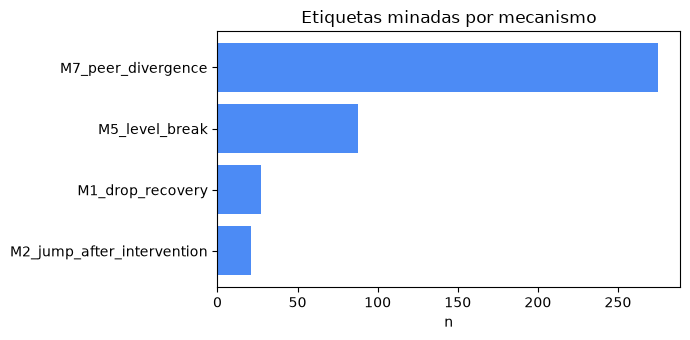

In [2]:
mined = mine_labels(cons, cust, cfg)
val = validate_against_confirmed(mined, labels)
print('Recall (todos):', f"{val['recall_all']:.1%}", '| confirmados:', val['confirmed'])
counts = mined.label_source.value_counts()
fig, ax = plt.subplots(figsize=(7,3.5))
ax.barh(counts.index[::-1], counts.values[::-1], color='#4c8bf5')
ax.set_title('Etiquetas minadas por mecanismo'); ax.set_xlabel('n')
plt.tight_layout(); plt.show()

## 2. Comparación de métodos PU — Precision@k

,elkan_noto,bagging_pu,spies
P@20,1.000,1.000,1.000
P@50,1.000,1.000,1.000
P@100,0.950,0.980,0.970
P@200,0.625,0.625,0.625


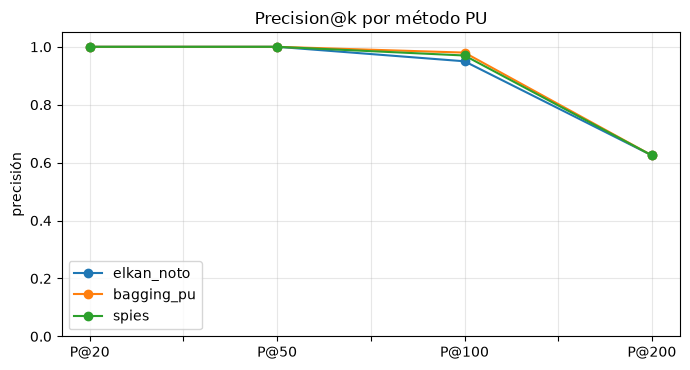

In [3]:
ks = [k for k in (20,50,100,200) if k <= cust.shape[0]]
rows = {}
for m in PU_METHODS:
    scores,_ = train_risk_model(cons, cust, labels, method=m, cfg=cfg)
    rows[m] = [precision_at_k(scores, truth, k) for k in ks]
dfp = pd.DataFrame(rows, index=[f'P@{k}' for k in ks])
display(dfp)
ax = dfp.plot(marker='o', figsize=(7,3.8))
ax.set_title('Precision@k por método PU'); ax.set_ylabel('precisión'); ax.set_ylim(0,1.05)
ax.grid(alpha=.3); plt.tight_layout(); plt.show()

## 3. Barrido de umbral — `drop_recovery_pct` (M1)

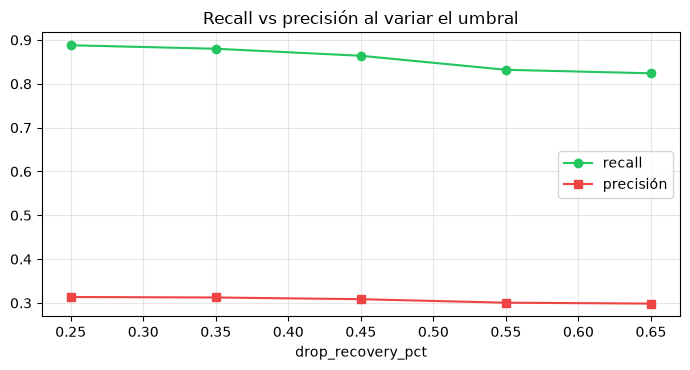

,umbral,recall,precision
0,0.25,0.888,0.3136
1,0.35,0.880,0.3125
2,0.45,0.864,0.3086
3,0.55,0.832,0.3006
4,0.65,0.824,0.2986


In [4]:
orig = cfg.thresholds['label_mining']['drop_recovery_pct']
rows=[]
for thr in (0.25,0.35,0.45,0.55,0.65):
    cfg.thresholds['label_mining']['drop_recovery_pct']=thr
    v = validate_against_confirmed(mine_labels(cons,cust,cfg), labels)
    rows.append((thr, v['recall_all'], v['precision_all_vs_confirmed']))
cfg.thresholds['label_mining']['drop_recovery_pct']=orig
sw = pd.DataFrame(rows, columns=['umbral','recall','precision'])
fig, ax = plt.subplots(figsize=(7,3.8))
ax.plot(sw.umbral, sw.recall, 'o-', label='recall', color='#22c55e')
ax.plot(sw.umbral, sw.precision, 's-', label='precisión', color='#ef4444')
ax.set_xlabel('drop_recovery_pct'); ax.legend(); ax.grid(alpha=.3)
ax.set_title('Recall vs precisión al variar el umbral'); plt.tight_layout(); plt.show()
sw

## Conclusiones
- Elige el **método PU** con mejor Precision@k en la cabeza del ranking (k pequeño).
- Fija el **umbral** en el punto de equilibrio recall/precisión que prefieras.
- Escribe los valores en `config/thresholds.yaml` y reejecuta `lossan run --force`.